## Contents

1. [Bartlett Beamformer Fundamentals](#bartlett-beamformer-fundamentals)
2. [Angular Resolution and Steering-Grid Sampling](#angular-resolution-and-steering-grid-sampling)

<a id="bartlett-beamformer-fundamentals"></a>

## Bartlett Beamformer Fundamentals

The Bartlett beamformer is a conventional delay-and-sum beamformer that evaluates the received spatial power for a set of candidate directions. For each steering angle $\theta$, the array snapshot is projected onto a weight vector matched to the corresponding steering vector.

For an $M$-element uniform linear array, the steering vector is

$$
\mathbf{a}(\theta)
=
\begin{bmatrix}
1 &
e^{-j 2\pi \frac{d}{\lambda}\sin\theta} &
\cdots &
e^{-j 2\pi (M-1)\frac{d}{\lambda}\sin\theta}
\end{bmatrix}^{T},
$$

where $d$ is the inter-element spacing and $\lambda$ is the wavelength.

The normalized Bartlett weight vector is

$$
\mathbf{w}_{\mathrm{B}}(\theta)
=
\frac{\mathbf{a}(\theta)}
{\sqrt{\mathbf{a}^{H}(\theta)\mathbf{a}(\theta)}}.
$$

For a uniformly weighted array, $\mathbf{a}^{H}(\theta)\mathbf{a}(\theta)=M$, and therefore

$$
\mathbf{w}_{\mathrm{B}}(\theta)
=
\frac{1}{\sqrt{M}}\mathbf{a}(\theta).
$$

For the spatial snapshot $\mathbf{x}[k]$, the beamformer output in the candidate direction $\theta$ is

$$
y(\theta,k)
=
\mathbf{w}_{\mathrm{B}}^{H}(\theta)\mathbf{x}[k].
$$

The output power is estimated by averaging over $L$ snapshots:

$$
\hat{P}_{\mathrm{B}}(\theta)
=
\frac{1}{L}
\sum_{k=0}^{L-1}
\left|
\mathbf{w}_{\mathrm{B}}^{H}(\theta)\mathbf{x}[k]
\right|^{2}.
$$

Using the sample covariance matrix

$$
\hat{\mathbf{R}}
=
\frac{1}{L}
\sum_{k=0}^{L-1}
\mathbf{x}[k]\mathbf{x}^{H}[k],
$$

the same Bartlett spatial spectrum can be written as

$$
\hat{P}_{\mathrm{B}}(\theta)
=
\mathbf{w}_{\mathrm{B}}^{H}(\theta)
\hat{\mathbf{R}}
\mathbf{w}_{\mathrm{B}}(\theta)
$$

or, directly in terms of the steering vector,

$$
\hat{P}_{\mathrm{B}}(\theta)
=
\frac{
\mathbf{a}^{H}(\theta)
\hat{\mathbf{R}}
\mathbf{a}(\theta)
}{
\mathbf{a}^{H}(\theta)\mathbf{a}(\theta)
}
$$

The Bartlett beamformer can therefore be interpreted as a bank of spatial filters, with each branch steered toward a different candidate angle.

<p align="center">
  <img
    src="../docs/images/bartlett_steering_grid.png"
    alt="Bartlett beamformer evaluated over an angular steering grid"
    width="60%">
</p>

Each spatial filter forms a coherent sum of the antenna signals after compensating for the phase progression expected from its steering direction. The squared magnitude of the filter output gives one sample of the Bartlett spatial power spectrum.

The spectrum is evaluated over a selected angular grid,

$$
\theta_i
\in
\left\{
\theta_0,\theta_1,\ldots,\theta_{K-1}
\right\},
$$

giving

$$
\hat{P}_{\mathrm{B}}(\theta_i)
=
\mathbf{w}_{\mathrm{B}}^{H}(\theta_i)
\hat{\mathbf{R}}
\mathbf{w}_{\mathrm{B}}(\theta_i),
\qquad
i=0,\ldots,K-1.
$$

Unlike the Spatial FFT, whose evaluation directions are determined by the FFT spatial-frequency bins, the Bartlett beamformer can be evaluated at arbitrary steering directions. A dense angular grid produces a smooth spectrum and reduces steering-grid mismatch, but it does not improve the fundamental angular resolution imposed by the finite array aperture.

<a id="angular-resolution-and-steering-grid-sampling"></a>

## Angular Resolution and Steering-Grid Sampling

### Angular Resolution

The angular resolution of the Bartlett beamformer is determined primarily by the physical aperture of the antenna array. Although the Bartlett spectrum can be evaluated on an arbitrarily dense angular grid, increasing the number of steering directions does not narrow the array main lobe or create additional resolving capability.

For a uniform linear array with half-wavelength element spacing, the approximate Rayleigh resolution in directional-cosine space,

$$
u=\sin\theta,
$$

is

$$
\Delta u_{\mathrm{res}}
\approx
\frac{2}{M},
$$

where $M$ is the number of antenna elements. For two targets at angles $\theta_1$ and $\theta_2$, their separation in directional-cosine space is

$$
\Delta u
=
\left|
\sin\theta_2-\sin\theta_1
\right|.
$$

The targets are approximately resolvable when

$$
\Delta u
\gtrsim
\frac{2}{M}.
$$

For a small angular separation around a center angle $\theta_0$,

$$
\sin\left(\theta_0+\Delta\theta\right)
-
\sin\theta_0
\approx
\cos\theta_0\,\Delta\theta,
$$

and therefore the angular resolution can be approximated as

$$
\Delta\theta_{\mathrm{res}}
\approx
\frac{2}{M\cos\theta_0}
$$

with $\Delta\theta_{\mathrm{res}}$ expressed in radians.

This relation shows that the angular resolution is best near broadside, where $\cos\theta_0$ is close to one, and degrades toward endfire. Consequently, two targets with the same angular separation may be resolved near broadside but appear as a single merged response when located farther off boresight.

The following example compares two target pairs with the same $18^\circ$ angular separation. For an eight-element ULA, the broadside pair produces two visible Bartlett-spectrum maxima, whereas the pair centered at $50^\circ$ produces an approximately merged response.

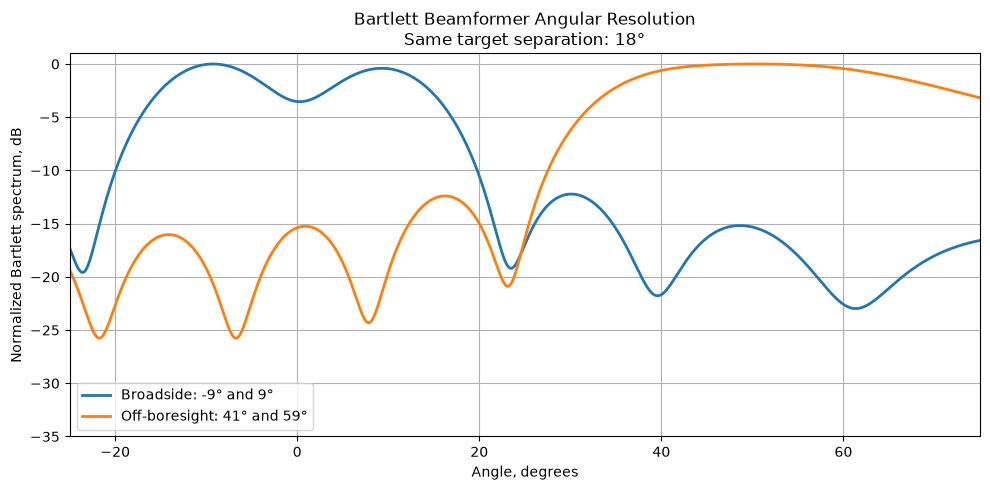

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
n_antennas = 8
n_snapshots = 512
angle_separation_deg = 18.0
snr_db = 40.0

# Dense Bartlett steering grid
angle_grid_deg = np.linspace(-90.0, 90.0, 3601)

# Same angular separation in both cases
broadside_targets_deg = np.array([
    -angle_separation_deg / 2,
    +angle_separation_deg / 2,
])

off_boresight_center_deg = 50.0
off_boresight_targets_deg = np.array([
    off_boresight_center_deg - angle_separation_deg / 2,
    off_boresight_center_deg + angle_separation_deg / 2,
])

rng = np.random.default_rng(7)
antenna_index = np.arange(n_antennas)

# ------------------------------------------------------------
# Half-wavelength ULA steering vector
# ------------------------------------------------------------
def steering_vector(angle_deg):
    angle_rad = np.deg2rad(angle_deg)

    return np.exp(
        1j * np.pi * antenna_index * np.sin(angle_rad)
    )


# ------------------------------------------------------------
# Simulate uncorrelated targets and calculate Bartlett spectrum
# ------------------------------------------------------------
def bartlett_beamformer_spectrum(target_angles_deg):
    target_steering_matrix = np.column_stack([
        steering_vector(angle)
        for angle in target_angles_deg
    ])

    # Independent complex target amplitudes across snapshots
    target_signals = (
        rng.standard_normal(
            (len(target_angles_deg), n_snapshots)
        )
        + 1j
        * rng.standard_normal(
            (len(target_angles_deg), n_snapshots)
        )
    ) / np.sqrt(2.0)

    snapshots = target_steering_matrix @ target_signals

    signal_power = np.mean(np.abs(snapshots) ** 2)
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))

    noise = np.sqrt(noise_power / 2.0) * (
        rng.standard_normal(snapshots.shape)
        + 1j * rng.standard_normal(snapshots.shape)
    )

    snapshots += noise

    # Sample covariance matrix
    covariance_matrix = (
        snapshots @ snapshots.conj().T
    ) / n_snapshots

    # Steering vectors for all candidate angles
    scan_steering_matrix = np.column_stack([
        steering_vector(angle)
        for angle in angle_grid_deg
    ])

    # Bartlett spectrum:
    # P_B(theta) = w^H(theta) R w(theta),
    # where w(theta) = a(theta) / sqrt(M)
    spectrum = np.real(
        np.einsum(
            "mk,mn,nk->k",
            scan_steering_matrix.conj(),
            covariance_matrix,
            scan_steering_matrix,
        )
    ) / n_antennas

    spectrum /= np.max(spectrum)

    return 10.0 * np.log10(
        np.maximum(spectrum, 1e-8)
    )


broadside_spectrum_db = bartlett_beamformer_spectrum(
    broadside_targets_deg
)

off_boresight_spectrum_db = bartlett_beamformer_spectrum(
    off_boresight_targets_deg
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    angle_grid_deg,
    broadside_spectrum_db,
    linewidth=2,
    label=(
        "Broadside: "
        f"{broadside_targets_deg[0]:.0f}° and "
        f"{broadside_targets_deg[1]:.0f}°"
    ),
)

plt.plot(
    angle_grid_deg,
    off_boresight_spectrum_db,
    linewidth=2,
    label=(
        "Off-boresight: "
        f"{off_boresight_targets_deg[0]:.0f}° and "
        f"{off_boresight_targets_deg[1]:.0f}°"
    ),
)

plt.xlabel("Angle, degrees")
plt.ylabel("Normalized Bartlett spectrum, dB")
plt.title(
    "Bartlett Beamformer Angular Resolution\n"
    f"Same target separation: {angle_separation_deg:.0f}°"
)
plt.xlim(-25, 75)
plt.ylim(-35, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

This example uses an $18^\circ$ angular separation. With an eight-element ULA, the broadside pair produces two visible maxima, whereas the pair centered at $50^\circ$ produces an approximately merged Bartlett response.

The same behavior is evaluated using measured AWR2243 data from two corner-reflector scenarios.

<p align="center">
  <img
    src="../docs/images/bartlett_broadside_off_boresight.png"
    alt="Measured Bartlett spectra for broadside and off-boresight target pairs"
    width="90%">
</p>

In the broadside scenario, the two reflectors are positioned approximately symmetrically around the radar boresight with a lateral separation of $2.0$ m. In the off-boresight scenario, the reflector pair is shifted away from boresight while maintaining the same lateral separation and a similar range.

The measured Bartlett spectra therefore demonstrate the degradation of angular resolution away from broadside: the broadside pair produces two distinguishable maxima, while the off-boresight pair forms a more strongly merged response.

### Steering-Grid Sampling

The Bartlett beamformer evaluates the spatial power spectrum at a user-defined set of steering directions. For a half-wavelength ULA, the steering variable can be expressed in terms of spatial frequency,

$$
u
=
\frac{d}{\lambda}\sin\theta
=
\frac{1}{2}\sin\theta.
$$

An $M$-point Spatial FFT evaluates the conventional beamformer only at the fixed spatial-frequency samples

$$
u_m
=
\frac{m}{M},
$$

where $m$ is the centered FFT-bin index. A target whose spatial frequency lies between these samples is therefore not evaluated exactly at its true direction. The nearest FFT bins observe reduced peak values, and the target energy is distributed across several bins.

The Bartlett beamformer is based on the same conventional beamforming principle,

$$
P_{\mathrm{B}}(\theta)
=
\mathbf{a}^{H}(\theta)
\hat{\mathbf{R}}
\mathbf{a}(\theta),
$$

but the steering vector can be evaluated at arbitrary candidate directions. A dense steering grid can therefore sample the beamformer response close to the actual target direction and reduce steering-grid mismatch.

For direct comparison with the FFT grid, a continuous Bartlett steering position can be expressed as an equivalent fractional FFT-bin index,

$$
q
=
M u
=
M\frac{d}{\lambda}\sin\theta.
$$

Integer values of $q$ coincide with the bins of an $M$-point Spatial FFT, whereas non-integer values represent directions between FFT bins.

A dense Bartlett grid improves spectrum sampling and peak localization, but it does not improve the physical angular resolution of the array. The main-lobe width and sidelobe structure remain determined by the finite aperture and spatial weighting. Similarly, zero-padding the Spatial FFT provides denser sampling of the same conventional beamformer response without increasing the actual array resolution.

The following example compares two targets aligned with the FFT bins and the same pair shifted by half a bin. The Spatial FFT is evaluated only at integer bin positions, while the Bartlett spectrum is evaluated over a dense grid around the two targets.

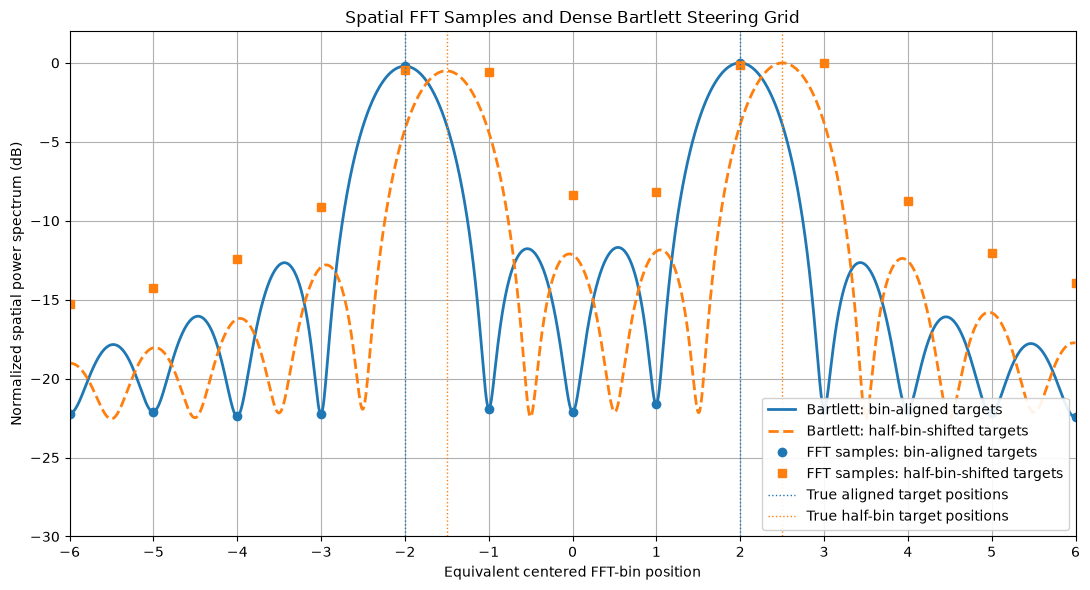

Bin-aligned target angles: [-7.181  7.181]
Half-bin-shifted target angles: [-5.379  8.989]
Aligned angular separation: 14.362 degrees
Mismatched angular separation: 14.369 degrees
Bartlett grid spacing: 0.0050 equivalent FFT bins


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
n_antennas = 32
n_snapshots = 512
snr_db = 10.0

# Centered FFT-bin positions of two targets
target_bins = np.array([-2.0, 2.0])

# Exact bin alignment and half-bin mismatch
aligned_bins = target_bins
mismatched_bins = target_bins + 0.5

# Dense Bartlett grid in the region containing both targets
bartlett_bin_grid = np.linspace(
    -6.0,
    6.0,
    2401,
)

rng = np.random.default_rng(12)
antenna_index = np.arange(n_antennas)

# ------------------------------------------------------------
# Spatial frequency and angle conversions
# ------------------------------------------------------------
def bin_to_spatial_frequency(bin_position):
    return np.asarray(bin_position) / n_antennas


def spatial_frequency_to_angle(spatial_frequency):
    return np.rad2deg(
        np.arcsin(2.0 * np.asarray(spatial_frequency))
    )


aligned_spatial_frequencies = bin_to_spatial_frequency(
    aligned_bins
)

mismatched_spatial_frequencies = bin_to_spatial_frequency(
    mismatched_bins
)

bartlett_spatial_frequency_grid = bin_to_spatial_frequency(
    bartlett_bin_grid
)

aligned_angles_deg = spatial_frequency_to_angle(
    aligned_spatial_frequencies
)

mismatched_angles_deg = spatial_frequency_to_angle(
    mismatched_spatial_frequencies
)

# ------------------------------------------------------------
# Generate spatial snapshots
# ------------------------------------------------------------
def generate_snapshots(target_spatial_frequencies):
    steering_matrix = np.column_stack([
        np.exp(
            1j
            * 2.0
            * np.pi
            * antenna_index
            * spatial_frequency
        )
        for spatial_frequency in target_spatial_frequencies
    ])

    # Independent complex source amplitudes
    target_signals = (
        rng.standard_normal(
            (
                len(target_spatial_frequencies),
                n_snapshots,
            )
        )
        + 1j
        * rng.standard_normal(
            (
                len(target_spatial_frequencies),
                n_snapshots,
            )
        )
    ) / np.sqrt(2.0)

    snapshots = steering_matrix @ target_signals

    signal_power = np.mean(
        np.abs(snapshots) ** 2
    )

    noise_power = signal_power / (
        10.0 ** (snr_db / 10.0)
    )

    noise = np.sqrt(noise_power / 2.0) * (
        rng.standard_normal(snapshots.shape)
        + 1j * rng.standard_normal(snapshots.shape)
    )

    return snapshots + noise


# ------------------------------------------------------------
# Spectrum normalization
# ------------------------------------------------------------
def normalize_power_spectrum_db(
    power,
    eps=1e-12,
):
    power = np.asarray(power, dtype=float)
    power = power / np.max(power)

    return 10.0 * np.log10(
        np.maximum(power, eps)
    )


# ------------------------------------------------------------
# M-point Spatial FFT
# ------------------------------------------------------------
def fft_beamformer_spectrum(snapshots):
    beam_output = np.fft.fftshift(
        np.fft.fft(
            snapshots,
            n=n_antennas,
            axis=0,
        ),
        axes=0,
    )

    power = np.mean(
        np.abs(beam_output) ** 2,
        axis=1,
    )

    return normalize_power_spectrum_db(power)


# ------------------------------------------------------------
# Bartlett beamformer on a dense steering grid
# ------------------------------------------------------------
def bartlett_beamformer_spectrum(
    snapshots,
    scan_spatial_frequencies,
):
    # Sample covariance matrix
    covariance_matrix = (
        snapshots @ snapshots.conj().T
    ) / snapshots.shape[1]

    scan_steering_matrix = np.exp(
        1j
        * 2.0
        * np.pi
        * antenna_index[:, None]
        * scan_spatial_frequencies[None, :]
    )

    # P_B(u) = a^H(u) R a(u)
    power = np.real(
        np.einsum(
            "mk,mn,nk->k",
            scan_steering_matrix.conj(),
            covariance_matrix,
            scan_steering_matrix,
            optimize=True,
        )
    )

    return normalize_power_spectrum_db(power)


# ------------------------------------------------------------
# Process one target configuration
# ------------------------------------------------------------
def calculate_spectra(target_spatial_frequencies):
    snapshots = generate_snapshots(
        target_spatial_frequencies
    )

    fft_spectrum_db = fft_beamformer_spectrum(
        snapshots
    )

    bartlett_spectrum_db = bartlett_beamformer_spectrum(
        snapshots=snapshots,
        scan_spatial_frequencies=(
            bartlett_spatial_frequency_grid
        ),
    )

    return fft_spectrum_db, bartlett_spectrum_db


aligned_fft_db, aligned_bartlett_db = calculate_spectra(
    aligned_spatial_frequencies
)

mismatched_fft_db, mismatched_bartlett_db = calculate_spectra(
    mismatched_spatial_frequencies
)

fft_bins = np.arange(
    -n_antennas // 2,
    n_antennas // 2,
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))

# Bartlett dense-grid spectra
aligned_line, = plt.plot(
    bartlett_bin_grid,
    aligned_bartlett_db,
    linewidth=2.0,
    label="Bartlett: bin-aligned targets",
)

mismatched_line, = plt.plot(
    bartlett_bin_grid,
    mismatched_bartlett_db,
    linewidth=2.0,
    linestyle="--",
    label="Bartlett: half-bin-shifted targets",
)

# FFT samples
plt.plot(
    fft_bins,
    aligned_fft_db,
    linestyle="None",
    marker="o",
    markersize=6,
    color=aligned_line.get_color(),
    label="FFT samples: bin-aligned targets",
)

plt.plot(
    fft_bins,
    mismatched_fft_db,
    linestyle="None",
    marker="s",
    markersize=6,
    color=mismatched_line.get_color(),
    label="FFT samples: half-bin-shifted targets",
)

# True target positions
for index, target_bin in enumerate(aligned_bins):
    plt.axvline(
        target_bin,
        linestyle=":",
        linewidth=1.0,
        color=aligned_line.get_color(),
        label=(
            "True aligned target positions"
            if index == 0
            else "_nolegend_"
        ),
    )

for index, target_bin in enumerate(mismatched_bins):
    plt.axvline(
        target_bin,
        linestyle=":",
        linewidth=1.0,
        color=mismatched_line.get_color(),
        label=(
            "True half-bin target positions"
            if index == 0
            else "_nolegend_"
        ),
    )

plt.xlabel("Equivalent centered FFT-bin position")
plt.ylabel("Normalized spatial power spectrum (dB)")
plt.title(
    "Spatial FFT Samples and Dense Bartlett Steering Grid"
)
plt.xlim(-6.0, 6.0)
plt.ylim(-30.0, 2.0)
plt.xticks(np.arange(-6, 7, 1))
plt.grid(True)
plt.legend(
    loc="lower right",
    framealpha=0.9,
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Numerical summary
# ------------------------------------------------------------
print(
    "Bin-aligned target angles:",
    np.round(aligned_angles_deg, 3),
)

print(
    "Half-bin-shifted target angles:",
    np.round(mismatched_angles_deg, 3),
)

print(
    "Aligned angular separation:",
    f"{np.diff(aligned_angles_deg)[0]:.3f} degrees",
)

print(
    "Mismatched angular separation:",
    f"{np.diff(mismatched_angles_deg)[0]:.3f} degrees",
)

print(
    "Bartlett grid spacing:",
    f"{np.diff(bartlett_bin_grid)[0]:.4f} equivalent FFT bins",
)

The bin-aligned targets coincide with integer Spatial FFT bins, so their maxima are sampled directly by the FFT beamformer. In this case, the FFT samples lie on the peaks of the densely evaluated Bartlett spectrum.

After both targets are shifted by half a bin, their directions fall between adjacent FFT steering directions. The FFT therefore samples the conventional beamformer response away from its true maxima, reducing the observed peak values and distributing the target energy across neighboring bins. The dense Bartlett grid evaluates intermediate steering directions and recovers maxima close to the actual fractional-bin target positions.

The Bartlett and Spatial FFT responses represent the same conventional beamforming principle. Their difference in this example is the sampling grid: the $M$-point FFT is restricted to $M$ fixed spatial-frequency bins, whereas Bartlett can be evaluated at arbitrary steering directions. A denser Bartlett grid improves peak localization and reduces grid mismatch, but it does not narrow the main lobes or improve the physical angular resolution of the array.